# Exercise Solutions: Image Processing

Hands-on practice applying filters, thresholding, and morphological operations to images. Use the image `rice.png` for this exercise.


1. Estimate the background of the image and make the background uniform. Plot intermediate steps.

In the sample image, the background illumination is brighter in the center of the image than at the bottom. As a preprocessing step before analysis, make the background uniform and then convert the image into a binary image. To make the background illumination more uniform, create an approximation of the background as a separate image and then subtract this approximation from the original image.
As a first step to creating a background approximation image, remove all the foreground (rice grains) using morphological opening. The opening operation has the effect of removing objects that cannot completely contain the structuring element. To remove the rice grains from the image, the structuring element must be sized so that it cannot fit entirely inside a single grain of rice. The example calls the strel function to create a disk-shaped structuring element with a radius of 15.

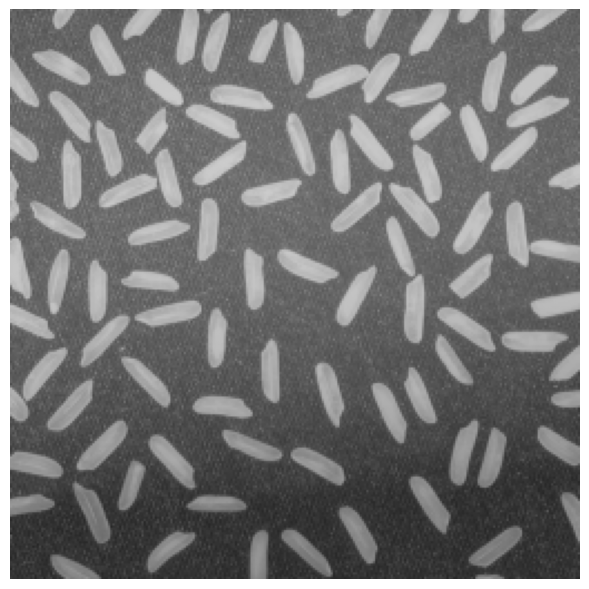

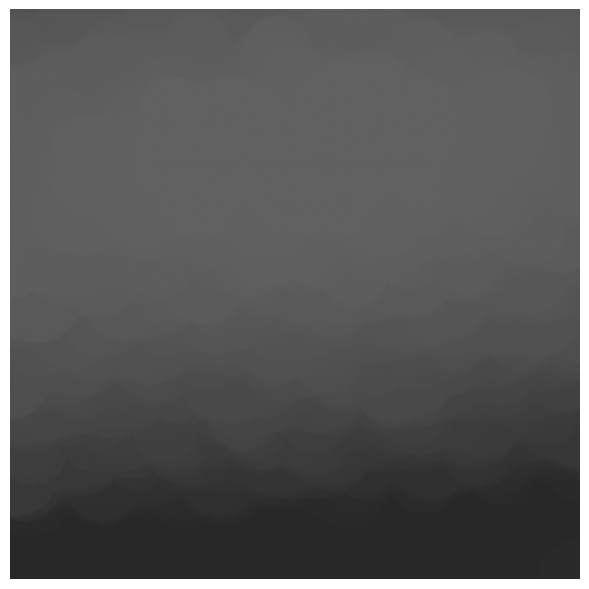

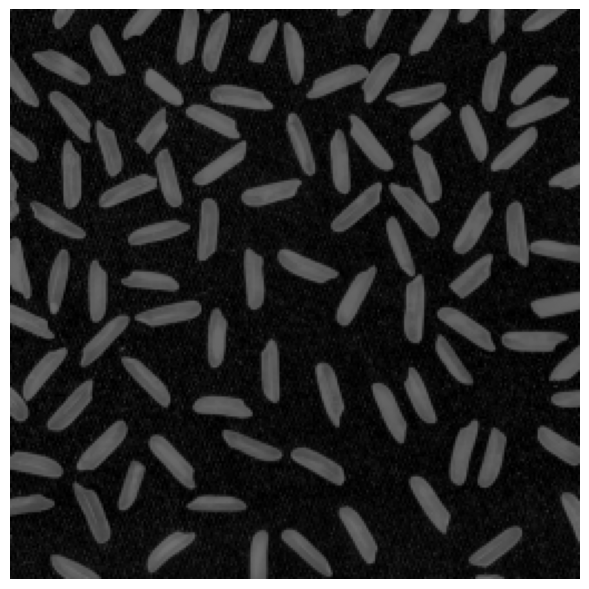

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
from skimage.exposure import rescale_intensity, histogram
from skimage.filters import threshold_otsu
from skimage.io import imread
from skimage.measure import label, regionprops
from skimage.morphology import area_opening, opening, disk, reconstruction
from iaf.morph.watershed import separate_neighboring_objects
from iaf.color import get_labels_cmap
from iaf.plot import imshow, show_labels
from iaf.notebook import init_style
init_style()

I = imread("illustrations/rice.png")
imshow(I)

# Structuring element
selem = disk(15)

# Run morphological opening
background = opening(I, selem)  # Very slow for large images!

imshow(background)

# Substract background

I2 = I - background

imshow(I2)

**Note**: for large images, morphological opening can be quite computationally intensive: [iaf.process.subtract_background](https://ia-res.ethz.ch/docs/iaf/process/index.html#iaf.process.subtract_background) implements a series of algorithms and optimizations to speed up the background subtraction.

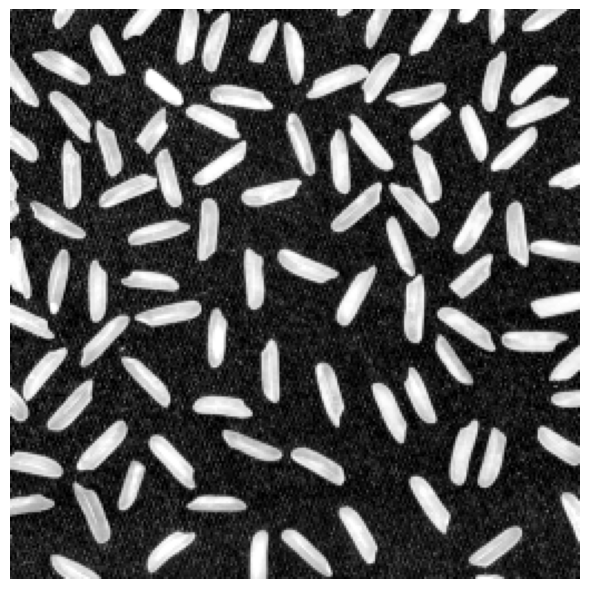

In [6]:
# The image is a bit dark. Let's stretch the intensities by dropping 1% of the intensities at both ends of the dynamic range.
p_low, p_high = np.percentile(I2, (1, 99))
I3 = rescale_intensity(I2, in_range=(p_low, p_high))

imshow(I3)

2. Use thresholding on the backgorund corrected image and plot the binary image.

We use the **Otsu** algorithm to find a threshold to segment the grains from the background-corrected image.

Threshold = 122


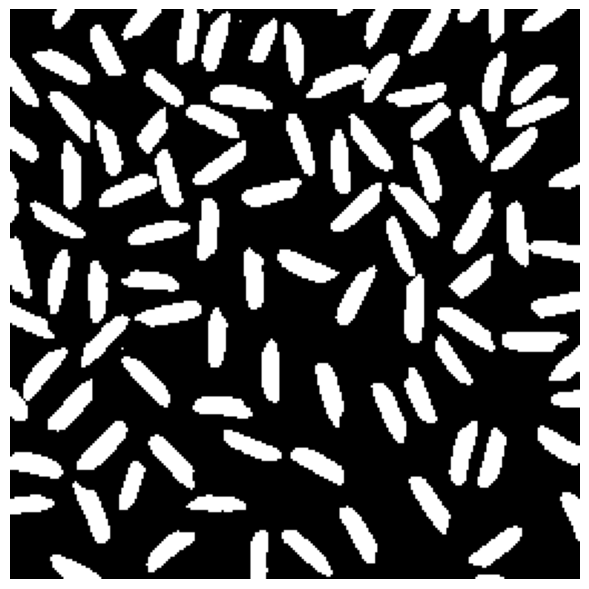

In [8]:
threshold = threshold_otsu(I3)
print(f"Threshold = {threshold}")
bw = I3 > threshold

imshow(bw)

3. Use morphological operations to clean segmentation artefacts.

We use **area opening** (a morphological operation with a non-fixed structuring elements of given area) to remove small objects.

**Note**: for a quicker alternative to `area_opening`, consider [iaf.morph.watershed.filter_labels_by_area](https://ia-res.ethz.ch/docs/iaf/morph/watershed/index.html#iaf.morph.watershed.filter_labels_by_area).


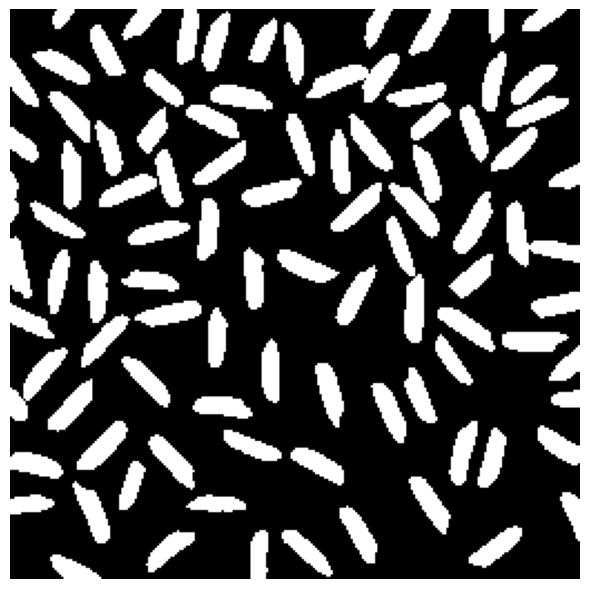

In [ ]:
bw = area_opening(bw, area_threshold=50)

imshow(bw)



4. Analyze the image and count the objects and compute the average and maximum object area.

Now that we have created a binary version of the original image, we can perform analysis of objects in the image. We will find all the **connected components** (objects) in the binary image. The accuracy of our results will depend on the size of the objects, the connectivity parameter (4, 8, or arbitrary), and whether or not any objects are touching (in which case they could be labeled as one object).

Found 95 connected components.
Median area = 190.0; max area = 404.0


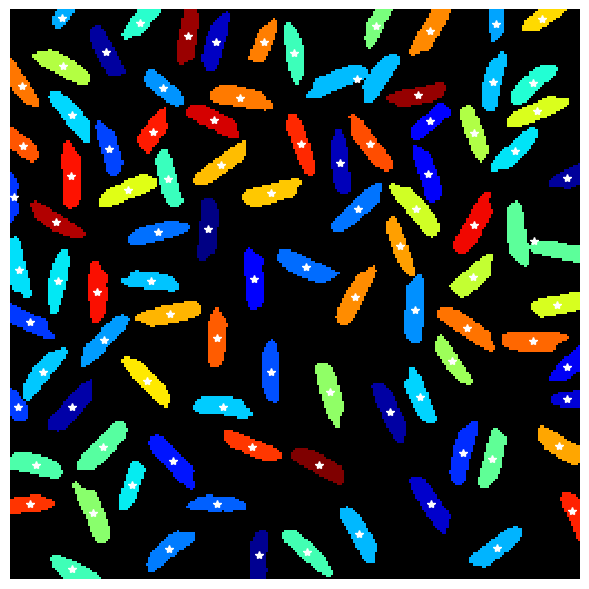

In [13]:
labels, num = label(bw, background=0, return_num=True, connectivity=1)
print(f"Found {num} connected components.")

show_labels(labels, plot_centroids=True)

props = regionprops(labels)

areas = []
for prop in props:
    areas.append(prop.area)

areas = np.array(areas)
print(f"Median area = {np.median(areas)}; max area = {areas.max()}")

5. Use watershed segmentation to compare the object count to step 4. Also compute the average and maximum object area.

The largest rice grain has twice the area of the median rice grain. This suggests that some of the rice grains were not properly segmented and resulted in the same connected component. Let's see how the largest grain looks like:

The largest object has area 236.0 and index 44.
Found 97 connected components.
Median area = 190.0; max area = 236.0


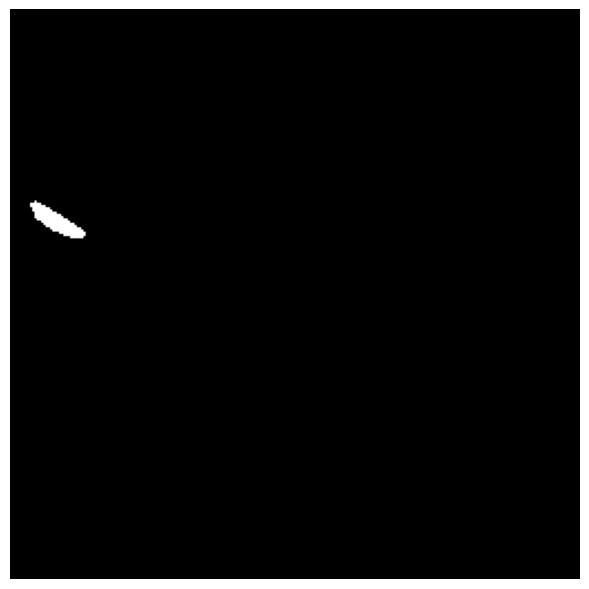

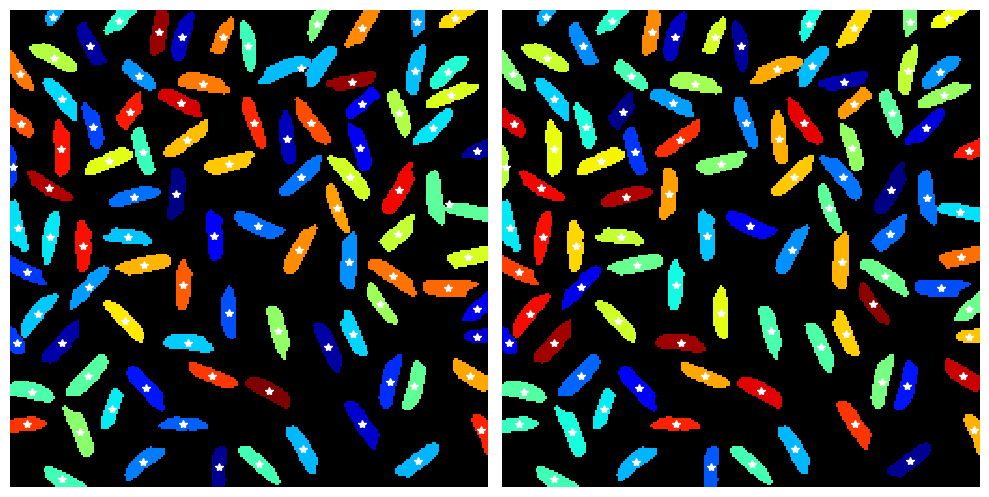

In [20]:
# We add 1 to the index since `areas` does not contain the background.
index = np.argmax(areas) + 1
print(f"The largest object has area {areas[index - 1]} and index {index}.")

bw_largest = np.where(labels == index, True, False)
imshow(bw_largest)

labels_ws, num_ws, _ = separate_neighboring_objects(bw, labels)
print(f"Found {num_ws} connected components.")

props = regionprops(labels_ws)

areas = []
for prop in props:
    areas.append(prop.area)

areas = np.array(areas)
print(f"Median area = {np.median(areas)}; max area = {areas.max()}")

fig, axes = plt.subplots(1, 2)
show_labels(labels, plot_centroids=True, ax=axes[0])
show_labels(labels_ws, plot_centroids=True,  ax=axes[1])

Looks better now.